In [1]:
import tsw
import numpy as np
from data import *
from data_utils import add_corresponding_terms, add_edges, f_ground_truth
from information_content import compute_information_content, deprecated, get_ancestors0

Correspondances trouvées : 550


/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


In [8]:
list(gt_set)

[(978, 1142),
 (977, 1183),
 (1557, 675),
 (2221, 1509),
 (1356, 1588),
 (1208, 292),
 (87, 153),
 (1081, 1011),
 (407, 243),
 (2219, 2222),
 (105, 207),
 (1764, 1907),
 (813, 522),
 (2204, 1196),
 (141, 538),
 (976, 1977),
 (1431, 980),
 (874, 1700),
 (516, 1992),
 (474, 1092),
 (354, 2079),
 (1860, 339),
 (1696, 582),
 (2157, 1465),
 (1282, 2025),
 (2051, 1304),
 (637, 188),
 (387, 1703),
 (1697, 317),
 (296, 124),
 (1276, 669),
 (1682, 45),
 (1594, 2147),
 (1705, 28),
 (1241, 1205),
 (97, 179),
 (236, 1277),
 (460, 2074),
 (1917, 707),
 (1076, 994),
 (1771, 998),
 (468, 882),
 (2200, 766),
 (857, 577),
 (643, 1786),
 (2163, 1113),
 (1623, 1922),
 (1306, 1083),
 (1293, 735),
 (590, 89),
 (356, 825),
 (13, 2149),
 (173, 1872),
 (1963, 1060),
 (660, 944),
 (217, 1915),
 (1310, 6),
 (1889, 765),
 (1868, 642),
 (1385, 445),
 (1970, 281),
 (2029, 1270),
 (898, 1904),
 (129, 230),
 (1720, 1832),
 (566, 1659),
 (785, 800),
 (1916, 2152),
 (542, 1338),
 (1833, 842),
 (686, 528),
 (557, 1875)

In [2]:
w_omim = work_omim.reset_index(drop=True)
w_orpha = work_orpha.reset_index(drop=True)
_, valid_omim, valid_orpha = f_ground_truth(w_omim, w_orpha, df_orpha_omim_exact)

w_omim = w_omim[w_omim['database_id'].isin(valid_omim)].reset_index(drop=True)
w_orpha = w_orpha[w_orpha['database_id'].isin(valid_orpha)].reset_index(drop=True)
hpo_cols0 = [c for c in w_omim.columns if c.startswith("HP:")]
gt_set, valid_omim0, valid_orpha0 = f_ground_truth(w_omim, w_orpha, df_orpha_omim_exact)
print(f"Taille OMIM : {w_omim.shape[0]}, ORPHA : {w_orpha.shape[0]}, paires GT : {len(gt_set)}")


Taille OMIM : 2237, ORPHA : 2237, paires GT : 2237


In [3]:
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols0}
w_omim_P = tsw.propagate_terms(w_omim,  hpo_cols, ancestors, depths, k=3)
w_orpha_P = tsw.propagate_terms(w_orpha, hpo_cols, ancestors, depths, k=3)

In [5]:
uniform = {node: 1.0 for node in G_hpo_work.nodes()}

tree = tsw.tsw(G_hpo_work, uniform)
tree._build_numba_structures()
C = tree.tsw_matrix(w_omim_P, w_orpha_P)
print(C)

100%|██████████| 9/9 [02:00<00:00, 13.43s/it]

[[12.431977   9.816329   9.689854  ... 10.600982  10.526108  10.697614 ]
 [11.817814   9.789592   8.852358  ... 10.331142  10.600875   8.967136 ]
 [13.019737  12.260339  11.6158285 ...  9.909372  10.672982  10.326921 ]
 ...
 [12.70833    8.906254  10.571021  ...  9.4384365  8.952202   9.776448 ]
 [11.306943  10.048807   9.32776   ...  8.377853   9.055635   7.8255787]
 [10.795907   9.114575   9.151303  ...  8.891857   9.120147   7.647399 ]]


In [6]:
ranks, pairs = tsw.transport(C, 0.05*np.mean(C), gt_set)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.486 (1088/2237)
Top-3 accuracy : 0.487 (1090/2237)
Top-5 accuracy : 0.487 (1090/2237)
 Rang moyen: 561.62
======== Avec régularisation ========
0.5794649
Paires évaluées : 2237
Top-1 accuracy : 0.474 (1060/2237)
Top-3 accuracy : 0.604 (1352/2237)
Top-5 accuracy : 0.667 (1491/2237)
 Rang moyen: 48.52


In [4]:
import networkx as nx
from collections import defaultdict
ic,_, _ = compute_information_content(work_omim, G_hpo_work)
ic = {t:-np.log(w) for t, w in ic.items()}
ic_max = max(ic.values())
ic = defaultdict(lambda: 0.0, ic)

tree = tsw.tsw(G_hpo_work, ic)
tree._build_numba_structures()
C = tree.tsw_matrix(w_omim_P, w_orpha_P)
print(C)

100%|██████████| 9/9 [02:25<00:00, 16.16s/it]

[[82.65581  69.65719  67.68499  ... 72.28383  73.12289  73.582375]
 [82.20843  70.56445  63.999554 ... 72.88978  76.33593  66.40098 ]
 [87.088066 86.69155  79.81714  ... 67.50102  75.400894 74.117195]
 ...
 [80.12402  63.170513 70.94414  ... 62.954727 61.855762 66.623276]
 [73.686386 73.83047  65.25725  ... 56.785007 64.00295  55.941414]
 [75.07853  70.74361  67.330536 ... 64.74384  67.83616  58.26979 ]]


In [5]:
ranks, pairs = tsw.transport(C, 0.03*np.mean(C), gt_set)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.527 (1179/2237)
Top-3 accuracy : 0.527 (1180/2237)
Top-5 accuracy : 0.528 (1181/2237)
 Rang moyen: 523.67
======== Avec régularisation ========
2.358879
Paires évaluées : 2237
Top-1 accuracy : 0.528 (1181/2237)
Top-3 accuracy : 0.659 (1474/2237)
Top-5 accuracy : 0.714 (1598/2237)
 Rang moyen: 45.14


In [5]:
tree = tsw.tsw(G_hpo_work, depths)
tree._build_numba_structures()
C = tree.tsw_matrix(w_omim, w_orpha)
print(C)

100%|██████████| 9/9 [02:19<00:00, 15.46s/it]

[[60.625004 43.94999  44.894268 ... 55.511387 52.703667 57.349983]
 [62.62496  47.674957 45.99037  ... 56.42043  46.760113 54.27494 ]
 [68.82271  58.49787  61.454193 ... 55.409107 54.03227  60.366962]
 ...
 [69.24246  49.05457  56.52104  ... 57.9546   52.158222 59.036366]
 [66.11597  56.98263  56.33283  ... 56.112675 55.454082 61.600018]
 [60.63664  47.301224 52.127316 ... 55.480053 49.411003 50.46589 ]]


In [8]:
ranks, pairs = tsw.transport(C, 0.05*np.mean(C), gt_set)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.449 (1004/2237)
Top-3 accuracy : 0.449 (1004/2237)
Top-5 accuracy : 0.450 (1006/2237)
 Rang moyen: 601.30
======== Avec régularisation ========
3.0227091
Paires évaluées : 2237
Top-1 accuracy : 0.446 (997/2237)
Top-3 accuracy : 0.574 (1284/2237)
Top-5 accuracy : 0.632 (1414/2237)
 Rang moyen: 55.31


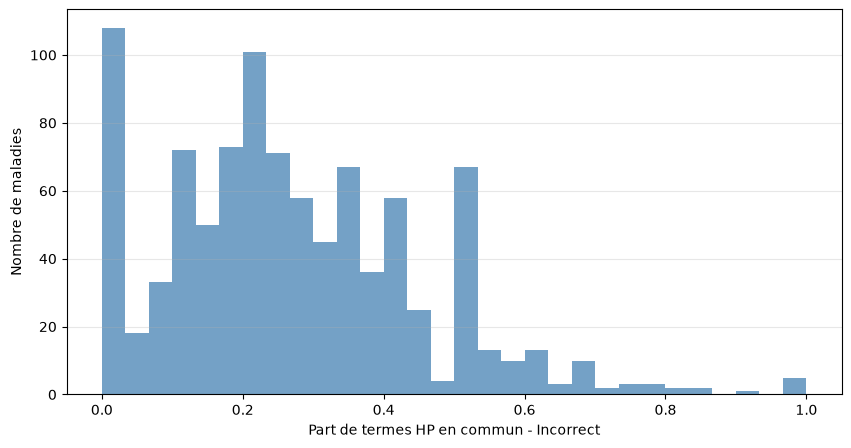

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
incorrect = [k for k, v in pairs.items() if (v[0] > 3 or v[0]==0)]

paires_zero_dict = {}
paires_correct_dict = {}
hpo_cols = [c for c in w_omim.columns if c.startswith('HP:')]
omim_to_idx = {v: i for i, v in enumerate(w_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(w_orpha['database_id'].values)}
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}

for (i,j) in incorrect:
    omim_row = w_omim.iloc[i][hpo_cols]
    orpha_row = w_orpha.iloc[j][hpo_cols]
    omim_hpos  = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    paires_zero_dict[(i, j)] = {
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
    }

var1 = [len(paires_zero_dict[c]["commun"])/paires_zero_dict[c]["omim"]["count"] for c in paires_zero_dict.keys()]

fig, ax = plt.subplots(figsize=(10, 5), sharex=True)

sns.histplot(var1, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes HP en commun - Incorrect")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.show()

In [13]:
import networkx as nx
import numpy as np

l = [len(nx.descendants(G_hpo_work, n)) for n in G_hpo_work.nodes()]
np.unique(l)

list(G_hpo_work.predecessors('HP:0000001'))

['HP:0000005',
 'HP:0000118',
 'HP:0012823',
 'HP:0020228',
 'HP:0032223',
 'HP:0032443',
 'HP:0040279']

In [ ]:
print('Union diseases')
union_diseases = add_corresponding_terms(work_omim, work_orpha, df_orpha_omim)
print('Add edges')
G_hpo_omim = add_edges(union_diseases, G_hpo_work, depths)
print("End of preprocessing")
G_hpo_omim.add_edge('HP:6001347', 'HP:0001832')

label_to_id = {node: str(i) for i, node in enumerate(G_hpo_omim.nodes())}
id_to_label = {v: k for k, v in label_to_id.items()}
G_clean = nx.relabel_nodes(G_hpo_omim, label_to_id)  # Nouveaux labels pour éviter les pollutions

objects = list(G_hpo_omim.nodes())
edges = np.array([(label_to_id[u], label_to_id[v]) for u, v in G_hpo_omim.edges()],dtype=int)
#nx.write_edgelist(G_clean, "graph.edg", delimiter="\t", data=False)
#nx.write_edgelist(G_hpo_omim, "graph.edg", delimiter="\t", data=False)

Union diseases


Fusion HPO: 100%|██████████| 5312/5312 [00:00<00:00, 6131.79it/s]


Add edges


100%|██████████| 6562/6562 [00:11<00:00, 560.81it/s]


End of preprocessing


In [3]:
nodes_to_keep = [c for c in union_diseases.columns if c.startswith('HP')]
G_sub = G_hpo_omim.subgraph(nodes_to_keep).copy()

print(f"Noeuds : {G_hpo_omim.number_of_nodes()} → {G_sub.number_of_nodes()}")
print(f"Arêtes : {G_hpo_omim.number_of_edges()} → {G_sub.number_of_edges()}")

Noeuds : 19391 → 11613
Arêtes : 2186608 → 2174438


In [3]:
import numpy as np
import pandas as pd

nodes = []
vectors = []

with open("graph.emb", "r") as f:
    next(f)
    i=0
    for line in f:
        i+=1
        parts = line.strip().split()
        try:
            vec = np.array(parts[1:], dtype=np.float32)
            nodes.append(parts[0])
            vectors.append(vec)
        except ValueError:
            print(f"Ligne {i} ignorée : {line[:]}")
df = pd.DataFrame(vectors, index=nodes)
df.index = [int(label_to_id[i]) for i in df.index]
df_sorted = df.sort_index()
max_id = df_sorted.index.max()
df_sorted = df_sorted.reindex(range(max_id + 1))
ignored_label = [c for c in id_to_label.keys() if not np.isin(int(c), df_sorted.index)]

Ligne 17214 ignorée : Comment: Affected individuals may present with foot pain on weight-bearing, swelling, and tenderness. Radiological features include widening of the metatarsophalangeal joint space and flattening of the affected metatarsal head, at later stages metatarsal head sclerosis, cortical thickening, and intra-articular loose bodies. Osteochondrosis is a condition resulting from an epiphysis injury that alters enchondral ossification and produces irregularity at the joint surface. Freiberg disease is characterized as osteochondrosis of the metatarsal heads (primarily the second)."", xrefs=('PMID:30685014', 'PMID:30725993')"")" 0.0821505 0.012895118 -0.067146435 -0.11278694 0.105025284 0.03998919 0.020470139 0.032430608 0.10429149 -0.099818945 0.06482978 -0.02671577 0.112023905 0.03470147 0.04848226 0.10817434 -0.09108107 0.02597665 -0.018610151 -0.07946276 -0.019600997 -0.004767047 -0.007365023 -0.086254686 -0.022665929 -0.06743415 0.052404623 -0.16472206 -0.019311633 -0.03

In [40]:
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import average_precision_score

def evaluate(weights, objects, edges, node2id):

    pos_neighbors = defaultdict(set)
    for u, v in edges:
        pos_neighbors[int(u)].add(int(v))
    w = weights.values
    n = w.shape[0]
    ap_scores = []
    ranks_all = []
    labels = np.zeros(n)

    for obj in tqdm(objects):
        u = int(node2id[obj])  # Identifiant du terme 
        neighbors = pos_neighbors.get(u, set())
        if not neighbors:
            continue
        if np.any(np.isnan(w[u])):
            continue
        u_emb = np.tile(w[u], (n, 1))
        dists = np.linalg.norm(u_emb-w, axis=1)
        dists[u] = float('inf')
        dists[np.isnan(dists)] = float('inf')

        max_finite = dists[np.isfinite(dists)].max()
        dists[~np.isfinite(dists)] = max_finite + 1.0

        sorted_ind = np.argsort(dists)
        ranks = np.where(np.isin(sorted_ind, list(neighbors)))[0] + 1

        n_neighbors = len(neighbors)
        corrected_ranks = ranks - np.arange(n_neighbors)
        ranks_all.extend(corrected_ranks.tolist())

        labels.fill(0)
        labels[list(neighbors)] = 1
        ap_scores.append(average_precision_score(labels, -dists))

    map_score  = float(np.mean(ap_scores))
    mean_rank  = float(np.mean(ranks_all))
    return map_score, mean_rank
  

In [41]:
results = evaluate(df_sorted, objects, edges, label_to_id)
results

100%|██████████| 19391/19391 [08:01<00:00, 40.31it/s]


(0.028388536478705838, 4453.802849255879)

In [5]:
from joblib import Parallel, delayed
from tqdm import tqdm
from OT_utils import compute_transport
from information_content import deprecated

def compute_costs_matrix_wasserstein2(df_omim, df_orpha, node2id_w, df_weights, deprecated):
    n=len(df_omim)
    m=len(df_orpha)
    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
    W = df_weights.values
    print(type(W))

    print("Precompute...")
    def precompute(df):
        '''
        Renvoie pour chaque maladie (ligne) du dataframe df la liste des termes HPO actifs et 
        le vecteur de poids uniformes associés.
        '''
        X = df[hpo_cols].to_numpy(dtype=bool)
        resolved_cols = np.array(
            [deprecated.get(col, col) if deprecated.get(col, col) in node2id_w else None for col in hpo_cols], 
            dtype=object)
        valid_mask = resolved_cols != None
        X_valid = X[:, valid_mask]
        resolved_valid = resolved_cols[valid_mask]
        terms = [list(resolved_valid[row_mask]) for row_mask in X_valid]
        weights = [np.ones(len(t)) / len(t) if t else np.array([]) for t in terms]
        return terms, weights

    terms_i, weights_i = precompute(df_omim)  # Termes actifs, poids pour les maladies sources
    terms_j, weights_j = precompute(df_orpha)  # Termes actifs, poids pour les maladies destinations
    print("Finished !")

    all_terms = list({h for ts in terms_i + terms_j for h in ts})  # Tous les termes actifs
    term2idx = {h: k for k, h in enumerate(all_terms)}
    missing = [h for h in all_terms if h not in node2id_w]
    print(f"Termes absents de node2id_w : {missing[:10]}")
    E = W[[int(node2id_w[h]) for h in all_terms]]  # Embeddings des termes actifs
    E = E.astype(np.float32)

    idx_i = [[term2idx[h] for h in ts] for ts in terms_i]  # Index des termes actifs par maladies sources
    idx_j = [[term2idx[h] for h in ts] for ts in terms_j]  # Index des termes actifs par maladies destinations

    C = np.zeros((n,m))

    print("Precomputing full HPO distance matrix...")
    #D_full = np.sum((E[:, None, :] - E[None, :, :]) ** 2, axis=-1)  # (K, K)
    norms = np.sum(E**2, axis=1)  # (K,)
    D_full = norms[:, None] + norms[None, :] - 2 * (E @ E.T)  # (K, K)
    D_full = np.maximum(D_full, 0)
    print(f"HPO distance matrix: {D_full.shape}")

    def compute_row(i):
        if not idx_i[i]:
            return i, np.zeros(len(terms_j))
        # Ei = E[idx_i[i]]
        row = np.zeros(len(terms_j))
        valid_js = [j for j in range(len(terms_j)) if idx_j[j]]
        for j in valid_js:
            # Ej = E[idx_j[j]]
            # M = cost_hpos(Ei, Ej) 
            M = D_full[np.ix_(idx_i[i], idx_j[j])]
            _, row[j] = compute_transport(M, weights_i[i], weights_j[j])
        return i, row
    
    results = Parallel(n_jobs=-1)(
        delayed(compute_row)(i) for i in tqdm(range(len(df_omim)), desc="OMIM")
    )
    C = np.zeros((len(df_omim), len(df_orpha)))
    for i, row in results:
        C[i] = row
    return C

C = compute_costs_matrix_wasserstein2(work_omim, work_orpha, label_to_id, df, deprecated)

<class 'numpy.ndarray'>
Precompute...
Finished !
Termes absents de node2id_w : []
Precomputing full HPO distance matrix...
HPO distance matrix: (10649, 10649)


OMIM: 100%|██████████| 6562/6562 [24:40<00:00,  4.43it/s]


In [7]:
from data_utils import f_ground_truth
w_omim = work_omim.reset_index(drop=True)
w_orpha = work_orpha.reset_index(drop=True)
_, valid_omim, valid_orpha = f_ground_truth(w_omim, w_orpha, df_orpha_omim)

w_omim = w_omim[w_omim['database_id'].isin(valid_omim)].reset_index(drop=True)
w_orpha = w_orpha[w_orpha['database_id'].isin(valid_orpha)].reset_index(drop=True)
hpo_cols0 = [c for c in w_omim.columns if c.startswith("HP:")]
gt_set, valid_omim0, valid_orpha0 = f_ground_truth(w_omim, w_orpha, df_orpha_omim)

In [9]:
from OT_utils import compute_transport, compute_transport_sinkhorn, evaluate_transport
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, None, None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C)

print("======== Avec régularisation ========")
epsilon = 0.1*np.mean(C)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C)

======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.000 (1/5312)
Top-3 accuracy : 0.001 (5/5312)
Top-5 accuracy : 0.001 (6/5312)
 Rang moyen: 1644.73
======== Avec régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.000 (1/5312)
Top-3 accuracy : 0.001 (4/5312)
Top-5 accuracy : 0.001 (6/5312)
 Rang moyen: 1584.41
